# Persistencia en Bases de Datos - SQLite

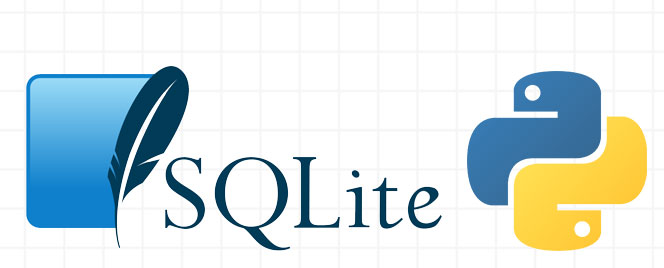

![SQLite](https://drive.google.com/uc?id=1RF5JhGN96u6n8CWGUvYD-TI63jjVJqxp)



* En el momento en el que instalamos Python, también instalamos otras herramientas. Una de ellas es **SQLite.**


* SQLite es un **sistema de gestión de bases de datos relacionales (RDBMS) integrado y basado en archivos** que se puede utilizar en nuestras aplicaciones de Python sin tener que instalar ningún software adicional.


* **Solo necesitamos importar** la biblioteca integrada de Python **sqlite3** para usar esta base de datos.



**En este Notebook, veremos cómo:**

1. Conectarse a una base de datos
2. Crear tablas
3. Insertar datos en tablas
4. Integación con Pandas.

## Crear una Conexión a la Base de Datos.

* Lo primero que tenemos que hacer es **crear una conexión a una base de datos.**

* Para hacerlo, solo necesitamos **importar sqlite3 y usar el método `.connect`.** 

* Dentro de paréntesis, escribimos el nombre de la base de datos que queremos crear. 


* En el ejemplo que vamos a hacer, lo llamaremos **"estudiantes.db"**

Crea un nuevo fichero en VSC que se llame: **mi_basededatos.py** 

In [1]:

import sqlite3 

# crear una conexión 
conexion = sqlite3.connect('estudiantes.db')

Si ejecutas el código anterior, se creará un nuevo archivo llamado "estudiantes.db" en tu directorio de trabajo:

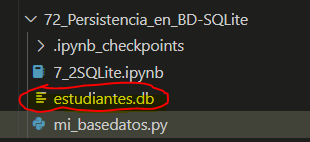

![image-2.png](https://drive.google.com/uc?id=1habXT9Bx7pLnn0MGhmbfljJ1_XNlkdX2)

## Crear una Tabla

* Antes de crear una tabla, necesitamos **crear un cursor.**


* Un cursor es un **objeto que se utiliza para realizar la conexión para ejecutar consultas SQL.**


* Usaremos el cursor para **crear tablas, insertar datos y más.**


* Para crear un cursor solo necesitamos **usar la conexión que hemos creado y el método `.cursor`.**

In [ ]:
c = conexion.cursor()

Después de eso, usamos el método **`.execute`** para **crear una nueva tabla en nuestra base de datos.** Dentro de las comillas, escribimos la sintaxis SQL:

In [ ]:
c.execute("""CREATE TABLE estudiantes (
            name TEXT,
            age INTEGER,
            height REAL
    )""")

### Tipos de Datos.

Como puedes ver, necesitamos definir el tipo de datos a medida que creamos las columnas de nuestra tabla. A diferencia de la mayoría de los Sistemas Gestores de Bases de Datos Relacionales que tienen docenas de tipos de datos, SQLite solo tiene 5 tipos de datos:

* **NULL: Valor nulo.**


* **INTEGER: números sin puntos decimales (p. ej., 1, 2, 3, 4)**


* **REAL: números con puntos decimales (p. ej., 6,2, 7,6, 11,2)**


* **TEXT: cualquier dato de carácter**


* **BLOB: colección de datos binarios almacenados como un valor en la base de datos. Nos permite almacenar documentos, imágenes y otros archivos multimedia en la base de datos.**


Finalmente, tenemos que confirmar y cerrar la conexión. Así es como se ve el código hasta ahora.

In [2]:
import sqlite3

# Creamos la conexión
conexion = sqlite3.connect('estudiantes.db')

# creamos el cursor
c = conexion.cursor()  # cursor

#cremos la tabla estudiantes
c.execute("""CREATE TABLE estudiantes (
            nombre TEXT,
            edad INTEGER,
            altura REAL
    )""")

# confirmamos los cambios
conexion.commit()

# cerramos la conexión.
conexion.close()

## Insertar Datos en una Tabla


* Para hacerlo, usamos de nuevo **`.execute`**, pero ahora usamos la declaración **INSERT INTO.**

In [3]:
#insertamos un alumno de nombre Pedro, edad 20 y altura 1.9
c.execute("INSERT INTO estudiantes VALUES ('Pedro', 20, 1.9)")

ProgrammingError: Cannot operate on a closed database.

**Nota:** 

Ten en cuenta que antes de ejecutar el código anterior, debes comentar la declaración **CREATE TABLE porque la tabla ya existe.**

También podemos insertar varias filas, pero en este caso, usamos el método `.executemany`. Además de eso, usamos ? como marcador de posición. Esto nos ayuda a agregar datos de una lista que nombramos all_estudiantes.

In [ ]:
#fijaros que cada elemento de la lista es una tupla con los valores de cada campo de la tabla.
all_estudiantes = [
    ('Jon', 21, 1.8),
    ('David', 35, 1.7),
    ('Maite', 19, 1.83),
]
# al insertar, en VALUES usamos los ? para indicarle que queremos que coja los valores de la lista all_estudiantes.
c.executemany("INSERT INTO estudiantes VALUES (?, ?, ?)", all_estudiantes)

## Seleccionar datos de una Tabla y Mostrarlos.

Hasta ahora hemos creado una tabla y le hemos puesto datos, pero aún no hemos visto nuestra tabla. 

Para ver nuestros datos, primero debemos **seleccionarlos** con la declaración **`SELECT` y luego mostrarlos con `.fetchall.`**

In [ ]:

# Seleccionamos los datos y los mostramos
c.execute("SELECT * FROM estudiantes")
print(c.fetchall())


En caso de que no quieras repetir estos pasos cada vez que quieras ver los datos en la tabla, puedes usar [SQLiteViewer](https://inloop.github.io/sqlite-viewer/) . Allí solo necesitas arrastrar tu archivo .db para ver su contenido.

El código completo hasta el momento es el siguiente:

In [4]:
import sqlite3

# Creamos la conexión
conexion = sqlite3.connect('estudiantes.db')

# creamos el cursor
c = conexion.cursor()  # cursor

#cremos la tabla estudiantes
'''c.execute("""CREATE TABLE estudiantes (
            nombre TEXT,
            edad INTEGER,
            altura REAL
    )""")'''

#fijaros que cada elemento de la lista es una tupla con los valores de cada campo de la tabla.
all_estudiantes = [
    ('Jon', 21, 1.8),
    ('David', 35, 1.7),
    ('Maite', 19, 1.83),
]
# al insertar, en VALUES usamos los ? para indicarle que queremos que coja los valores de la lista all_estudiantes.
c.executemany("INSERT INTO estudiantes VALUES (?, ?, ?)", all_estudiantes)

# Seleccionamos los datos y los mostramos
c.execute("SELECT * FROM estudiantes")
print(c.fetchall())

# confirmamos los cambios
conexion.commit()

# cerramos la conexión.
conexion.close()

[('Jon', 21, 1.8), ('David', 35, 1.7), ('Maite', 19, 1.83)]


## Trabajando con Pandas y SQLite 

SQLite puede integrarse con Pandas. Trabajaremos con un archivo CSV llamado **population_total.csv** que puedes descargar en EVEX. Este fichero recoge la evolución de la población por paises.

Tenemos dos formas de cargar los datos de un fichero:

* **En una Base de Datos en Memoria.**

* **En una Base de Datos Física.**

Inspeccionemos los datos del Dataframe:

In [2]:
import pandas as pd
df = pd.read_csv("population_total.csv")


In [3]:
df.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


### Base de Datos en Memoria

Ahora vamos a crear una base de datos SQLite en memoria. Para hacerlo, primero, necesitamos instalar sqlalchemy:

**`pip install sqlalchemy`**

Necesitamos crear un motor.

In [11]:
!pip install sqlalchemy

In [25]:
from sqlalchemy import create_engine, text
#cremos un motor o cursor
engine = create_engine('sqlite://', echo=False)
conexion = engine.connect()

Ahora adjuntemos el marco de datos a una tabla en nuestra base de datos (no es necesario crear la tabla con anticipación). En este caso, adjuntaremos el df a una tabla que denominaremos "población".

In [26]:
df.to_sql("poblacion", con=engine)

4185

Podemos ver nuestra tabla ejecutando un select con el siguiente código:

In [27]:

query = text("SELECT * FROM poblacion LIMIT 20")
result = conexion.execute(query)
for row in result:
    print(row)

(0, 'China', 2020.0, 1439323776.0)
(1, 'China', 2019.0, 1433783686.0)
(2, 'China', 2018.0, 1427647786.0)
(3, 'China', 2017.0, 1421021791.0)
(4, 'China', 2016.0, 1414049351.0)
(5, 'China', 2015.0, 1406847870.0)
(6, 'China', 2010.0, 1368810615.0)
(7, 'China', 2005.0, 1330776380.0)
(8, 'China', 2000.0, 1290550765.0)
(9, 'China', 1995.0, 1240920535.0)
(10, 'China', 1990.0, 1176883674.0)
(11, 'China', 1985.0, 1075589361.0)
(12, 'China', 1980.0, 1000089235.0)
(13, 'China', 1975.0, 926240885.0)
(14, 'China', 1970.0, 827601394.0)
(15, 'China', 1965.0, 724218968.0)
(16, 'China', 1960.0, 660408056.0)
(17, 'China', 1955.0, 612241554.0)
(18, 'France', 2020.0, 65273511.0)
(19, 'France', 2019.0, 65129728.0)


### Base de Datos en Fichero



Si deseamos crear un archivo sqlite (en lugar de una base de datos en memoria), debemos crear un motor con una base de datos de archivos.

Vamos a crear un archivo **mydb.db** y luego adjuntar el df a la tabla **"población".**

De nuevo, podemos usar  **`.fetchall`** para ver la tabla o usar SQLite Viewer.

In [30]:
from sqlalchemy import create_engine
engine = create_engine("sqlite:///mydb.db")
conexion = engine.connect()
#df.to_sql("poblacion", engine)# ojo puede dar error si se ejecuta varias veces.

In [31]:
resultados = conexion.execute(text("SELECT * FROM poblacion LIMIT 20")).fetchall()
for resultado in resultados:
    print(resultado)

(0, 'China', 2020.0, 1439323776.0)
(1, 'China', 2019.0, 1433783686.0)
(2, 'China', 2018.0, 1427647786.0)
(3, 'China', 2017.0, 1421021791.0)
(4, 'China', 2016.0, 1414049351.0)
(5, 'China', 2015.0, 1406847870.0)
(6, 'China', 2010.0, 1368810615.0)
(7, 'China', 2005.0, 1330776380.0)
(8, 'China', 2000.0, 1290550765.0)
(9, 'China', 1995.0, 1240920535.0)
(10, 'China', 1990.0, 1176883674.0)
(11, 'China', 1985.0, 1075589361.0)
(12, 'China', 1980.0, 1000089235.0)
(13, 'China', 1975.0, 926240885.0)
(14, 'China', 1970.0, 827601394.0)
(15, 'China', 1965.0, 724218968.0)
(16, 'China', 1960.0, 660408056.0)
(17, 'China', 1955.0, 612241554.0)
(18, 'France', 2020.0, 65273511.0)
(19, 'France', 2019.0, 65129728.0)


### Consultas


Un solo criterio de búsqueda:

**Seleccionamos por pais**

In [34]:
pais = input("Introduce un pais del que quieras conocer la evolución de su población: ")
query = text("SELECT * FROM poblacion WHERE country = ?")            

resultados = conexion.execute(query,(pais,)).fetchall()
if resultados:
    for resultado in resultados:
        print(resultado)    
else:
    print(f"No se han encontrado resultados con los criterios introducidos: {pais}")

Introduce un pais del que quieras conocer la evolución de su población:  spain


ArgumentError: List argument must consist only of tuples or dictionaries

Varios criterios de busqueda.

**Seleccionamos por país y año**

In [16]:
pais = input("Introduce un pais del que quieras conocer la evolución de su población: ")
year= int(input("Introduce el año: "))
query = text("""SELECT * FROM poblacion
            WHERE country = ? 
            and   year    = ?
            """)

resultados = engine.execute(query,(pais,year)).fetchall()
if resultados:
    for resultado in resultados:
        print(resultado)    
else:
    print(f"No se han encontrado resultados con los criterios introducidos: {pais}, {year}")

Introduce un pais del que quieras conocer la evolución de su población: Spain
Introduce el año: 2015
(3814, 'Spain', 2015.0, 46671926.0)
